## 1. Environment Setup

In [14]:
import sys
sys.path.insert(0, '/home/snt/projects_lujun/agi_index_tournament/src')

from agi_toolkit.DictRewriter import DictRewriter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import time

# Set up chart styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Dependencies imported successfully")

✓ Dependencies imported successfully


## 2. Initialize DictRewriter (Single and Multi-Source)

In [15]:
# Initialize multiple rewriter configurations
print("=" * 80)
print("Initializing DictRewriter with Different Source Configurations")
print("=" * 80)

# Configuration 1: Default (WordNet + FastText)
rewriter = DictRewriter()
print(f"\n✓ Default Rewriter (WordNet + FastText)")
print(f"  Active sources: {rewriter.get_active_sources()}")
print(f"  Aggregation method: {rewriter.aggregation_method}")

# Configuration 2: WordNet only (fastest)
rewriter_wn = DictRewriter(sources=['wordnet'])
print(f"\n✓ WordNet-Only Rewriter")
print(f"  Active sources: {rewriter_wn.get_active_sources()}")

# Configuration 3: Multi-source with FASS
rewriter_multi = DictRewriter(
    sources=['wordnet', 'fass'],
    aggregation_method='ranked'
)
print(f"\n✓ Multi-Source Rewriter (WordNet + FASS, Ranked)")
print(f"  Active sources: {rewriter_multi.get_active_sources()}")
print(f"  Aggregation method: {rewriter_multi.aggregation_method}")

print("\n" + "=" * 80)

Initializing DictRewriter with Different Source Configurations
✓ DictRewriter initialized with sources: ['wordnet', 'fasttext']
  Aggregation method: ranked

✓ Default Rewriter (WordNet + FastText)
  Active sources: ['wordnet', 'fasttext']
  Aggregation method: ranked
✓ DictRewriter initialized with sources: ['wordnet']
  Aggregation method: ranked

✓ WordNet-Only Rewriter
  Active sources: ['wordnet']
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: ranked

✓ Multi-Source Rewriter (WordNet + FASS, Ranked)
  Active sources: ['wordnet', 'fass']
  Aggregation method: ranked



/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:94: UserWarning: fasttext package not installed. Install with: pip install fasttext
  warnings.warn("fasttext package not installed. Install with: pip install fasttext")
/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:141: UserWarning: sense2vec package not installed. Install with: pip install sense2vec
  warnings.warn("sense2vec package not installed. Install with: pip install sense2vec")


## 3. Test 1: Word Sense Disambiguation

In [16]:
# Test handling of polysemous words
ambiguous_sentence = """"
Four people—A, B, C, and D—are standing in a line from left to right. Each person is either a Truth-teller (always tells the truth) or a Liar (always lies).
They make the following statements:
A: "B is a liar."
B: "C and D are the same type (both truth-tellers or both liars)."
C: "Exactly one of A and D is a truth-teller."
D: "A and C are different types."
Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.
"""

ambiguous_sentence = """"
Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.
"""
print(f"Input sentence: {ambiguous_sentence}\n")

wsd_result = rewriter.wsd_sentence(ambiguous_sentence)

# Create result table
wsd_df = pd.DataFrame([
    {
        "Word": item["word"],
        "POS": item["pos"],
        "Synonym Count": len(item["synonyms"]),
        "Definition (first 50 chars)": item["gloss"][:50] if item["gloss"] else "N/A",
        "Synonym Examples": ", ".join(item["synonyms"][:2]) if item["synonyms"] else "N/A"
    }
    for item in wsd_result
])

print("Word Sense Disambiguation Results:")
print(wsd_df.to_string(index=False))
print(f"\nTotal words processed: {len(wsd_result)}")

Input sentence: "
Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.


Word Sense Disambiguation Results:
        Word  POS  Synonym Count                        Definition (first 50 chars)             Synonym Examples
          ``   ``              0                                                N/A                          N/A
        Task   NN              6 a specific piece of work required to be done as a                  chore, labor
           :    :              0                                                N/A                          N/A
   Determine   NN             15                                                N/A                find out, see
         for   IN              0                                                N/A                          N/A
        each   DT              4 to or from every one of two or more (considered in        apiece, from each one
    

## 4. Test 2: Comparison of Different Replacement Ratios

In [17]:
# Test different replacement ratios
test_text = "Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction."
ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print(f"Original text: {test_text}\n")
print("="*120)

def highlight_differences(original, rewritten):
    """Highlight differences between original and rewritten text"""
    orig_words = original.split()
    rewr_words = rewritten.split()
    
    result = []
    for i, (orig, rewr) in enumerate(zip(orig_words, rewr_words)):
        if orig.lower() == rewr.lower():
            result.append(f"{orig}")
        else:
            result.append(f"[{orig}→{rewr}]") 
    
    return " ".join(result)

for ratio in ratios:
    rewritten, _ = rewriter.rewrite(test_text, ratio=ratio, is_replace_by_description=False)
    print(f"\nRatio {ratio*100:3.0f}%: {rewritten}")

Original text: Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.


Ratio   0%: Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.

Ratio  20%: Task : shape for each person ( A , B , C , D ) whether they are a Truth-teller or a Liar , and briefly justify your answer using solely logical deduction .

Ratio  40%: Task : Determine for each mortal ( A , B , C , D ) whether they are a Truth-teller or a Liar , and in brief absolve your answer using only logical discount .

Ratio  60%: Task : see for each person ( A , B , C , D ) whether they make up a Truth-teller or a Liar , and in short justify your answer utilise alone consistent entailment .

Ratio  80%: undertaking : influence for each soul ( A , B , C , D ) whether they are a Truth-teller or a Liar , and briefly apologise your response apply

In [ ]:
# Compare results from different dictionary sources
test_text = "This is a good and fast project with excellent algorithms."

print("=" * 100)
print("Multi-Source Dictionary Comparison")
print("=" * 100)
print(f"\nOriginal text:\n{test_text}\n")

# Rewrite with different sources
result_wn, _ = rewriter_wn.rewrite(test_text, ratio=0.5)
result_default, _ = rewriter.rewrite(test_text, ratio=0.5)
result_multi, _ = rewriter_multi.rewrite(test_text, ratio=0.5)

print(f"WordNet only:\n  {result_wn}")
print(f"\nWordNet + FastText (Ranked):\n  {result_default}")
print(f"\nWordNet + FASS (Ranked):\n  {result_multi}")

# Show synonym details for key words
print("\n" + "=" * 100)
print("Multi-Source Synonym Details")
print("=" * 100)

wsd_results = rewriter.wsd_sentence(test_text)
test_words = ['good', 'fast', 'project', 'excellent']

for item in wsd_results:
    if item['word'].lower() in test_words and item['synonyms']:
        print(f"\nWord: '{item['word']}' (POS: {item['pos']})")
        print(f"  Ranked synonyms: {item['synonyms'][:5]}")
        
        # Show breakdown by source
        if 'source_synonyms' in item:
            print(f"  Source breakdown:")
            for source_name, syns in item['source_synonyms'].items():
                if syns and source_name != 'ranked':
                    print(f"    - {source_name:10s}: {syns[:3]}")

## 6. Test 4: Multi-line Text Processing

In [5]:
# Compare different aggregation strategies
test_sentence = "This is good."
test_rewrite = "This is a good project."

print("\n" + "=" * 100)
print("Aggregation Strategy Comparison")
print("=" * 100)

aggregation_methods = ['ranked', 'union', 'intersection']
results_by_strategy = {}

for strategy in aggregation_methods:
    print(f"\n--- Strategy: {strategy.upper()} ---")
    
    rewriter_strategy = DictRewriter(
        sources=['wordnet', 'fass'],
        aggregation_method=strategy
    )
    
    # Get WSD results to show synonyms
    wsd_results = rewriter_strategy.wsd_sentence(test_sentence)
    for item in wsd_results:
        if item['word'].lower() == 'good' and item['synonyms']:
            print(f"Word '{item['word']}' synonyms ({strategy}): {item['synonyms'][:8]}")
    
    # Show rewrite result
    rewritten, _ = rewriter_strategy.rewrite(test_rewrite, ratio=0.5)
    print(f"Rewritten text: {rewritten}")
    results_by_strategy[strategy] = rewritten

print("\n" + "=" * 100)


Aggregation Strategy Comparison

--- Strategy: RANKED ---
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: ranked
Word 'good' synonyms (ranked): ['proficient', 'in effect', 'beneficial', 'trade good', 'adept', 'full', 'unspoiled', 'commodity']
Rewritten text: This exist a good project .

--- Strategy: UNION ---
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: union
Word 'good' synonyms (union): ['practiced', 'positive', 'adept', 'great', 'soundly', 'secure', 'undecomposed', 'unspoiled']
Rewritten text: This be a good project .

--- Strategy: INTERSECTION ---
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: intersection
Word 'good' synonyms (intersection): ['good']
Rewritten text: This be a good project .



/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:94: UserWarning: fasttext package not installed. Install with: pip install fasttext
  warnings.warn("fasttext package not installed. Install with: pip install fasttext")
/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:141: UserWarning: sense2vec package not installed. Install with: pip install sense2vec
  warnings.warn("sense2vec package not installed. Install with: pip install sense2vec")


## Test 3b: Aggregation Strategy Comparison

In [6]:
# Test structure preservation in multi-line text
multiline_text = """Assume everything else about the patient and hospital at that time remains the same unless it must change because of the intervention (i.e., use standard intervention semantics).
Here's a single English question that tests logical (deductive) reasoning with clear, checkable constraints (similar in spirit to formal logic/analytical reasoning puzzles often used in standardized logic sections).
Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.
"""

print("Original text:")
print(multiline_text)
print("\n" + "="*80 + "\n")

rewritten, _ = rewriter.rewrite(multiline_text, ratio=0.5)
print("Rewritten text (replacement ratio=0.3):")
print(rewritten)

# Verify line count is preserved
original_lines = multiline_text.count('\n')
rewritten_lines = rewritten.count('\n')
print(f"\n✓ Line preservation verification: Original {original_lines+1} lines = Rewritten {rewritten_lines+1} lines ✓")

Original text:
Assume everything else about the patient and hospital at that time remains the same unless it must change because of the intervention (i.e., use standard intervention semantics).
Here's a single English question that tests logical (deductive) reasoning with clear, checkable constraints (similar in spirit to formal logic/analytical reasoning puzzles often used in standardized logic sections).
Task: Determine for each person (A, B, C, D) whether they are a Truth-teller or a Liar, and briefly justify your answer using only logical deduction.



Rewritten text (replacement ratio=0.3):
seize everything else about the patient and infirmary at that clock time persist the like unless it must variety because of the intervention ( i.e. , expend measure intervention semantics ) .
Hera 's a single English question that tests logical ( deductive ) abstract thought with clean-cut , checkable restraint ( similar in spirit to conventional logic/analytical conclude stupefy frequently use

## 7. Performance Analysis

In [7]:
# Performance comparison across different source configurations
test_text = "The project develops powerful algorithms for machine learning applications in modern technology."

print("\n" + "=" * 100)
print("Multi-Source Performance Analysis")
print("=" * 100 + "\n")

source_configs = [
    {'name': 'WordNet only', 'sources': ['wordnet']},
    {'name': 'WordNet + FastText', 'sources': ['wordnet', 'fasttext']},
    {'name': 'WordNet + FASS', 'sources': ['wordnet', 'fass']},
]

perf_data = []

for config in source_configs:
    rewriter_perf = DictRewriter(sources=config['sources'])
    
    # Time the rewriting
    start_time = time.time()
    rewritten, _ = rewriter_perf.rewrite(test_text, ratio=0.5)
    elapsed = (time.time() - start_time) * 1000  # Convert to ms
    
    # Count changes
    changes = sum(1 for w1, w2 in zip(test_text.split(), rewritten.split()) if w1 != w2)
    
    perf_data.append({
        'Configuration': config['name'],
        'Sources': str(config['sources']),
        'Time (ms)': f"{elapsed:.2f}",
        'Words Changed': changes,
        'Sample Output': rewritten[:60] + "..."
    })

perf_comparison_df = pd.DataFrame(perf_data)
print(perf_comparison_df.to_string(index=False))
print("\n" + "=" * 100)


Multi-Source Performance Analysis

✓ DictRewriter initialized with sources: ['wordnet']
  Aggregation method: ranked
✓ DictRewriter initialized with sources: ['wordnet', 'fasttext']
  Aggregation method: ranked
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: ranked
     Configuration                 Sources Time (ms)  Words Changed                                                   Sample Output
      WordNet only             ['wordnet']     17.91              9 The project develops knock-down algorithmic rule for auto le...
WordNet + FastText ['wordnet', 'fasttext']      4.22              4 The project develops right algorithms for machine learning a...
    WordNet + FASS     ['wordnet', 'fass']      4.51              5 The see modernize powerful algorithms for machine study appl...



## Test 6b: Multi-Source Performance Analysis

In [8]:
# Test performance on texts of different lengths
test_texts = {
    "Short text (5 words)": "The cat sat on mat.",
    "Medium text (20 words)": "The quick brown fox jumps over the lazy dog while running through the forest near the river.",
    "Long text (50 words)": "Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. Deep learning uses neural networks with multiple layers to process complex patterns in data."
}

performance_data = []

for name, text in test_texts.items():
    word_count = len(text.split())
    
    start_time = time.time()
    rewritten, wsd_info = rewriter.rewrite(text, ratio=0.3)
    elapsed_time = (time.time() - start_time) * 1000  # Convert to milliseconds
    
    performance_data.append({
        "Type": name,
        "Word Count": word_count,
        "Execution Time (ms)": f"{elapsed_time:.2f}",
        "Average Time per Word (ms)": f"{elapsed_time/word_count:.4f}"
    })

perf_df = pd.DataFrame(performance_data)
print("Performance Analysis Results:")
print(perf_df.to_string(index=False))

Performance Analysis Results:
                  Type  Word Count Execution Time (ms) Average Time per Word (ms)
  Short text (5 words)           5                8.92                     1.7835
Medium text (20 words)          17               36.52                     2.1485
  Long text (50 words)          35               29.89                     0.8539


## 8. Visualization 1: Synonym Distribution

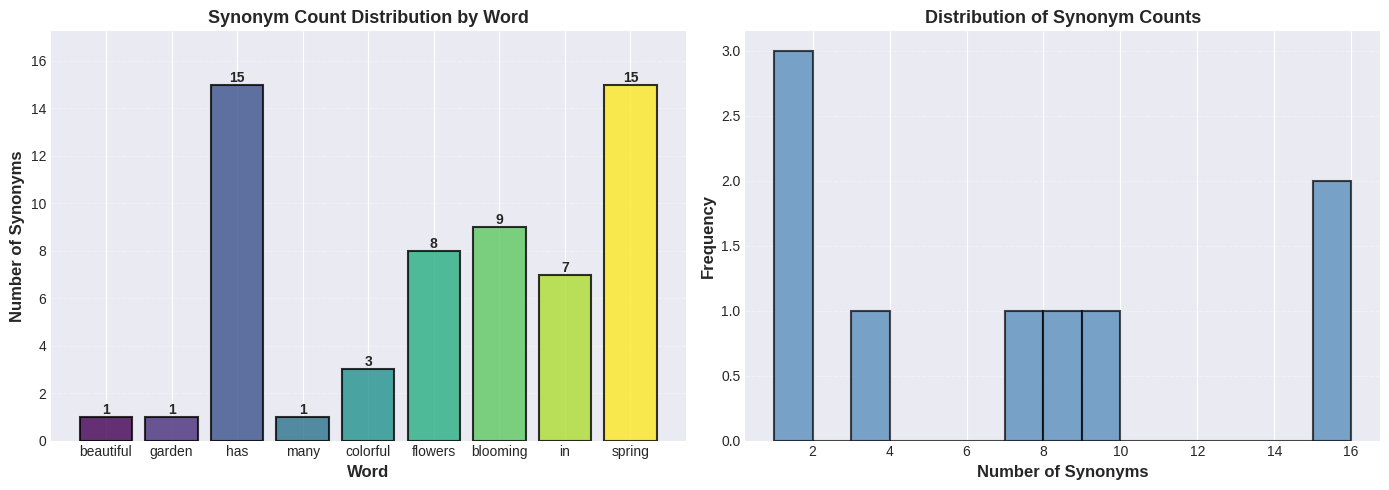


📊 Synonym Statistics:
  Words with synonyms: 9
  Average synonym count: 6.67
  Maximum synonym count: 15
  Minimum synonym count: 1


In [9]:
# Analyze distribution of synonym counts
test_text = "The beautiful garden has many colorful flowers blooming in spring."
wsd_result = rewriter.wsd_sentence(test_text)

synonym_counts = [len(item["synonyms"]) for item in wsd_result if item["synonyms"]]
words = [item["word"] for item in wsd_result if item["synonyms"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(words)))
bars = ax1.bar(words, synonym_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Word', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Synonyms', fontsize=12, fontweight='bold')
ax1.set_title('Synonym Count Distribution by Word', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(synonym_counts)*1.15)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Distribution histogram
ax2 = axes[1]
ax2.hist(synonym_counts, bins=range(1, max(synonym_counts)+2), 
         color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Number of Synonyms', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Synonym Counts', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n📊 Synonym Statistics:")
print(f"  Words with synonyms: {len(synonym_counts)}")
print(f"  Average synonym count: {np.mean(synonym_counts):.2f}")
print(f"  Maximum synonym count: {np.max(synonym_counts)}")
print(f"  Minimum synonym count: {np.min(synonym_counts)}")

## 9. Visualization 2: Impact Analysis of Replacement Ratio

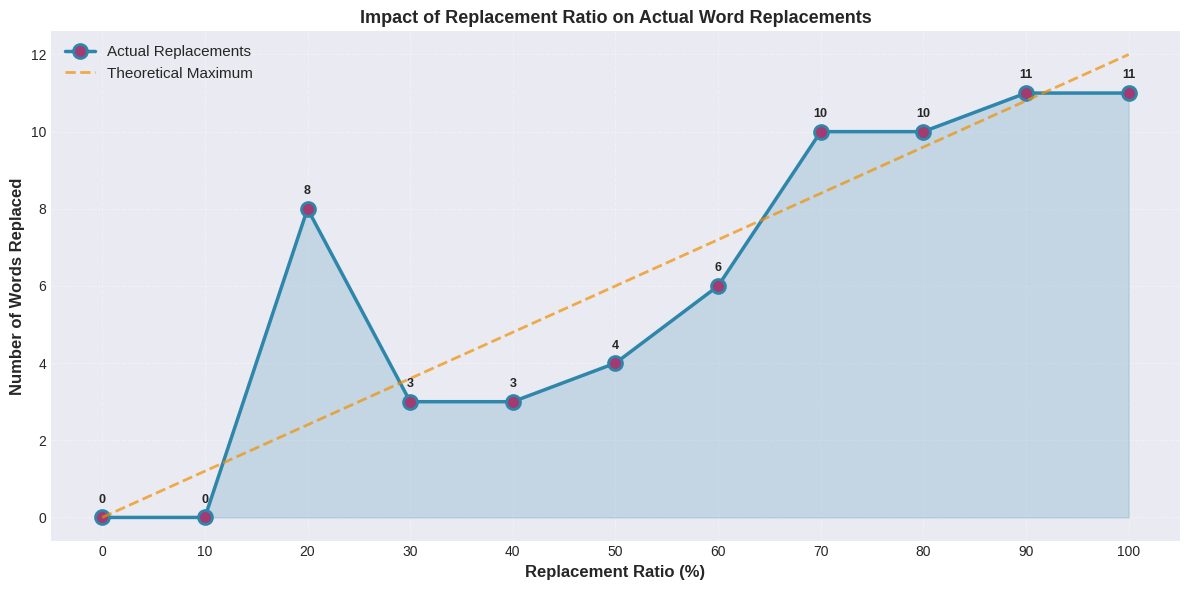


📊 Replacement Statistics:
  Total word count: 12
  Replacements at ratio=0.0: 0
  Replacements at ratio=1.0: 11
  Maximum replacements: 11


In [10]:
# Test the effect of different replacement ratios
test_text = "The project develops powerful algorithms for machine learning applications in modern technology."
ratios = np.linspace(0, 1, 11)

replacement_counts = []

for ratio in ratios:
    rewritten, wsd_info = rewriter.rewrite(test_text, ratio=ratio)
    # Calculate number of changed words
    changes = sum(1 for w1, w2 in zip(test_text.split(), rewritten.split()) if w1 != w2)
    replacement_counts.append(changes)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the curve
line = ax.plot(ratios * 100, replacement_counts, marker='o', linewidth=2.5, 
               markersize=10, color='#2E86AB', markerfacecolor='#A23B72', 
               markeredgewidth=2, markeredgecolor='#2E86AB', label='Actual Replacements')

# Theoretical replacement line
total_words = len(test_text.split())
theoretical_line = ax.plot(ratios * 100, ratios * total_words, '--', linewidth=2, 
                           color='#F18F01', label='Theoretical Maximum', alpha=0.7)

# Fill area
ax.fill_between(ratios * 100, replacement_counts, alpha=0.2, color='#2E86AB')

ax.set_xlabel('Replacement Ratio (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Words Replaced', fontsize=12, fontweight='bold')
ax.set_title('Impact of Replacement Ratio on Actual Word Replacements', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(range(0, 101, 10))
ax.legend(fontsize=11, loc='upper left')

# Add value labels
for i, count in enumerate(replacement_counts):
    ax.text(ratios[i] * 100, count + 0.3, str(count), 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Replacement Statistics:")
print(f"  Total word count: {total_words}")
print(f"  Replacements at ratio=0.0: {replacement_counts[0]}")
print(f"  Replacements at ratio=1.0: {replacement_counts[-1]}")
print(f"  Maximum replacements: {max(replacement_counts)}")

## 10. Visualization 3: POS Tag Distribution Analysis

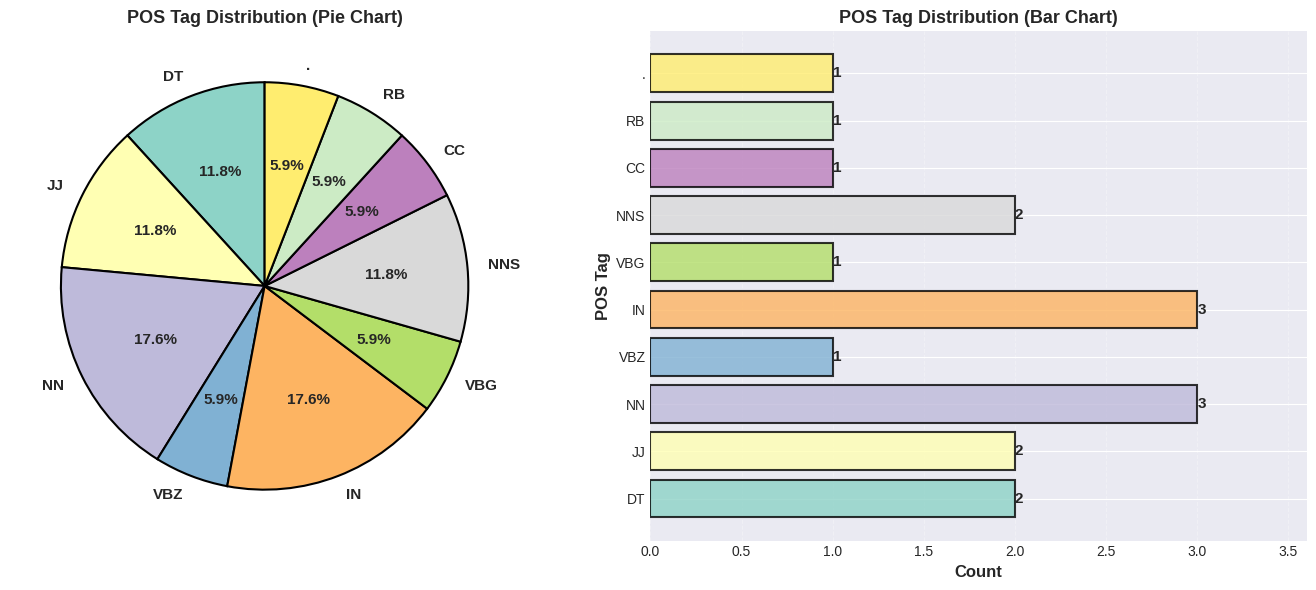


📊 POS Tag Statistics:
  NN    :  3 items
  IN    :  3 items
  DT    :  2 items
  JJ    :  2 items
  NNS   :  2 items
  VBZ   :  1 items
  VBG   :  1 items
  CC    :  1 items
  RB    :  1 items
  .     :  1 items


In [11]:
# Analyze POS tag distribution
test_text = "The quick brown fox jumps over the lazy dog while running through forests and streams rapidly."
wsd_result = rewriter.wsd_sentence(test_text)

# Extract POS tags
pos_tags = [item["pos"] for item in wsd_result if item["pos"]]
pos_counter = Counter(pos_tags)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(pos_counter)))
wedges, texts, autotexts = ax1.pie(pos_counter.values(), labels=pos_counter.keys(), 
                                     autopct='%1.1f%%', colors=colors, startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax1.set_title('POS Tag Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Horizontal bar chart
ax2 = axes[1]
tags = list(pos_counter.keys())
counts = list(pos_counter.values())
bars = ax2.barh(tags, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Count', fontsize=12, fontweight='bold')
ax2.set_ylabel('POS Tag', fontsize=12, fontweight='bold')
ax2.set_title('POS Tag Distribution (Bar Chart)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_xlim(0, max(counts)*1.2)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 POS Tag Statistics:")
for pos_tag, count in pos_counter.most_common():
    print(f"  {pos_tag:6s}: {count:2d} items")

In [13]:
# Test custom FASS (Fast-Sense Dictionary) integration
import json
import tempfile

print("\n" + "=" * 100)
print("Custom FASS Dictionary Integration Test")
print("=" * 100)

# Create custom domain-specific synonyms
custom_fass = {
    "good": ["excellent", "outstanding", "fantastic", "superior"],
    "bad": ["poor", "terrible", "awful", "inferior"],
    "fast": ["quick", "rapid", "swift", "speedy"],
    "slow": ["sluggish", "gradual", "leisurely", "unhurried"],
    "big": ["large", "huge", "enormous", "gigantic"],
    "small": ["tiny", "little", "compact", "miniature"]
}

# Save to temporary file
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    json.dump(custom_fass, f, indent=2)
    fass_path = f.name

print(f"\n✓ Created custom FASS dictionary with {len(custom_fass)} entries")
print(f"  Sample entries: {list(custom_fass.items())[:2]}")

# Initialize rewriter with custom FASS
rewriter_custom_fass = DictRewriter(sources=['wordnet', 'fass'])
rewriter_custom_fass.add_fass_dictionary(fass_path)

# Test text
test_text = "This is a good and fast project."

print(f"\nTest text: {test_text}")

# Without custom FASS
rewriter_base = DictRewriter(sources=['wordnet'])
rewritten_base, _ = rewriter_base.rewrite(test_text, ratio=1.0)
print(f"\nWithout custom FASS: {rewritten_base}")

# With custom FASS
rewritten_fass, _ = rewriter_custom_fass.rewrite(test_text, ratio=1.0)
print(f"With custom FASS:    {rewritten_fass}")

# Compare synonyms
print(f"\nSynonym Comparison:")
wsd_custom = rewriter_custom_fass.wsd_sentence(test_text)
for item in wsd_custom:
    if item['word'].lower() in ['good', 'fast'] and item['synonyms']:
        print(f"  '{item['word']}': {item['synonyms'][:5]}")

print("\n" + "=" * 100)


Custom FASS Dictionary Integration Test

✓ Created custom FASS dictionary with 6 entries
  Sample entries: [('good', ['excellent', 'outstanding', 'fantastic', 'superior']), ('bad', ['poor', 'terrible', 'awful', 'inferior'])]
✓ DictRewriter initialized with sources: ['wordnet', 'fass']
  Aggregation method: ranked
✓ FASS dictionary loaded from /tmp/tmpf1i_n6id.json

Test text: This is a good and fast project.
✓ DictRewriter initialized with sources: ['wordnet']
  Aggregation method: ranked

Without custom FASS: This make up a soundly and riotous cast .
With custom FASS:    This make up a full and degraded image .

Synonym Comparison:
  'good': ['proficient', 'in effect', 'beneficial', 'trade good', 'adept']
  'fast': ['profligate', 'flying', 'loyal', 'libertine', 'fasting']



/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:94: UserWarning: fasttext package not installed. Install with: pip install fasttext
  warnings.warn("fasttext package not installed. Install with: pip install fasttext")
/home/snt/projects_lujun/agi_index_tournament/src/agi_toolkit/SynonymSources.py:141: UserWarning: sense2vec package not installed. Install with: pip install sense2vec
  warnings.warn("sense2vec package not installed. Install with: pip install sense2vec")
